In [1]:
from collections import defaultdict
from matplotlib.legend_handler import HandlerTuple
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve

# Fine-tuning specific elements globally
plt.rcParams['font.size'] = 11     # Title font size
plt.rcParams['axes.titlesize'] = 16     # Title font size
plt.rcParams['axes.labelsize'] = 14     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 11    # X-axis tick font size
plt.rcParams['ytick.labelsize'] = 11    # Y-axis tick font size
plt.rcParams['legend.fontsize'] = 10    # Legend font size

def read_data_csv(fname):
    '''For the XRF CSVs. Doesn't work for the rest.'''
    def concentration(val):
        if len(val.strip()) == 0:
            return np.NAN
        if val.find('%') > 0:
            val = val[:val.index('%')].strip()
            return float(val)/100
        elif val.find('PPM') >0 :
            val = val[:val.index('PPM')].strip()
            return float(val)/1e6
        else:
            raise Exception('No fraction format found.')
    
    converters = {
        'Concentration': concentration,
        'Stat. error': concentration,
        'Stat. error.1': concentration,
        'LLD': concentration,
        'Total CSE': concentration,
        }
    df =  pd.read_csv(fname, index_col=0, converters=converters)
    # Add the error bar values to each relevant column.
    df['concentration_error'] = df['Concentration']*df['Stat. error']
    return df

def val_or_nan(df, field_name):
    r = np.NAN
    try:
        r = df.loc[field_name]
    except:
        pass
    return r

def rock(sample_name):
    '''Convert names like JWL 1-2 to JWL 1'''
    s = sample_name.split('-')
    return s[0]

def avg_by_sample(df, field):
    '''Dataframe must have sample field with JWL 1-2 format'''
    avg = defaultdict(float)
    counts = defaultdict(int)
    for s in df['Sample']:
        row = df[df.Sample == s]
        # This strips rows that contain only NaN, we want them back later.
        if np.isnan(row.iloc[0][field]):
            continue
        avg[rock(s)] += row.iloc[0][field]
        counts[rock(s)] += 1
    for k,v in avg.items():
        avg[k] = v/counts[k]
    # We backfill the rows that contain only NaN
    for k in df['Sample']:
        if not rock(k) in avg:
            avg[rock(k)] = np.nan
    return pd.Series(data=avg.values(), index=avg.keys())
    


In [2]:
# Data loading and wrangling for XRF

idx =     ['Sand 1', 'Sand 2', 'Sand 3', 'JWL 1-1', 'JWL 1-2', 'JWL 2-1', 'JWL 2-2', 'JWL 3-1', 'JWL 3-2', 'JWL 4-1', 'JWL 4-2', 'JWL 5-1',  'JWL 5-2', 'JWL 6-1', 'JWL 6-2', 'JWL 7-1', 'JWL 7-2', 'JWL 8-1', 'JWL 8-2', 'JWL 9-1', 'JWL 9-2', 'JWL 11-1', 'JWL 11-2', 'JWL 12-1', 'JWL 12-2']
compton = [ 1.09,     1.1,      1.11,     0.85,      0.86,      0.92,       0.94,      0.9,       0.9,      0.94,      0.93,      0.96,       0.92,     0.94,       0.96,      0.76,      0.75,      0.92 ,     0.87,      0.84,      0.83,      0.96,       0.98,       0.86,       0.86]
# We keep Sand for completeness, but we never actually care about it.
samples = idx[3:]
d = [read_data_csv('jwl-1-1.csv'),
     read_data_csv('jwl-1-2.csv'),
     read_data_csv('jwl-2-1.csv'),
     read_data_csv('jwl-2-2.csv'),
     read_data_csv('jwl-3-1.csv'),
     read_data_csv('jwl-3-2.csv'),
     read_data_csv('jwl-4-1.csv'),
     read_data_csv('jwl-4-2.csv'),
     read_data_csv('jwl-5-1.csv'),
     read_data_csv('jwl-5-2.csv'),
     read_data_csv('jwl-6-1.csv'),
     read_data_csv('jwl-6-2.csv'),
     read_data_csv('jwl-7-1.csv'),
     read_data_csv('jwl-7-2.csv'),
     read_data_csv('jwl-8-1.csv'),
     read_data_csv('jwl-8-2.csv'),
     read_data_csv('jwl-9-1.csv'),
     read_data_csv('jwl-9-2.csv'),
     read_data_csv('jwl-11-1.csv'),
     read_data_csv('jwl-11-2.csv'),
     read_data_csv('jwl-12-1.csv'),
     read_data_csv('jwl-12-2.csv'),
     # The sand data is useless for analysis.
    #  read_data_csv('sand1.csv'),
    #  read_data_csv('sand2.csv'),
    #  read_data_csv('sand3.csv'),
     ]
xrf_data = pd.DataFrame(index=samples, data={'Data': d, 'Compton': compton[3:]})

# Pulls data from the second line in the original data file when that data is more reliable.
# This dict has to be updated manually for each dataset and element.
line2_corrections = {
    'JWL 2-1': ['Ba'],
    'JWL 5-1': ['Ba'],
    'JWL 8-2': ['Ba'],
    'JWL 12-2': ['Ba'],
    }
for k,v in line2_corrections.items():
    c = xrf_data.loc[k].Data.loc[v]['Calc. concentration.1'] / 100
    e = xrf_data.loc[k].Data.loc[v]['Stat. error.1']
    xrf_data.loc[k, 'Data'].loc[v, 'Concentration'] = c # pyright: ignore[reportAttributeAccessIssue]
    xrf_data.loc[k, 'Data'].loc[v, 'Stat. error'] = e # pyright: ignore[reportAttributeAccessIssue]
    xrf_data.loc[k, 'Data'].loc[v, 'concentration_error'] = c * e # pyright: ignore[reportAttributeAccessIssue]

# There is no sand data anymore, so these lines are useless unless we 
#enable sand again.
# sand1 = data.loc['Sand 1'].Data
# sr = val_or_nan(sand1, 'Sr')
# We drop the sand samples for the main dataframe.
# xrf_data = xrf_data.loc[samples]

# jwl82 = xrf_data.loc['JWL 8-2'].Data

OSM = 'OSM'
USM = 'USM'
UMM = 'UMM'
FLYSCH = 'Flysch'
OTHER = 'other'
FRESH = 'Fresh'
MARINE = 'Marine'
SAMPLE = 'Sample'
STANDARD = 'Reference'

sample_type = {
    'Sand 1': OTHER,
    'Sand 2': OTHER,
    'Sand 3': OTHER,
    'JWL 1': USM,
    'JWL 2': USM,
    'JWL 3': USM,
    'JWL 4': USM,
    'JWL 5': USM,
    'JWL 6': FLYSCH,
    'JWL 7': OSM,
    'JWL 8': UMM,
    'JWL 9': UMM,
    'JWL 11': UMM,
    'JWL 12': UMM,
    'BCR2': OTHER,
}

salinity = {
    USM: FRESH,
    OSM: FRESH,
    UMM: MARINE,
    FLYSCH: MARINE,
    OTHER: OTHER,
}

type_color = {
    USM: 'green',
    UMM: 'blue',
    FLYSCH: 'blue',
    OSM: 'green',
    OTHER: 'grey'
}

type_symbol = {
    USM: 'o',
    UMM: 'o',
    FLYSCH: '^',
    OSM: '^',
    OTHER: 'x'
}

QUALTIY_HIGH = 'high'
QUALITY_LOW = 'bad'

def xrf_quality(compton):
    if compton <= 0.9 and compton <=1.1:
        return QUALTIY_HIGH
    else:
        return QUALITY_LOW
    
quality_marker = {
    QUALTIY_HIGH: 'o',
    QUALITY_LOW: 'X',
}

def data_column(element, field, df):
    res = []
    for s in df.index:
        sd = df.loc[s].Data
        # extra = [s, df.loc[s][element]]
        try:
            e = sd.loc[element]            
            res.append(e[field]) # type: ignore
        except:
            res.append(np.NaN)
    return res

# Make dataframes for each result type.
# XRF results have the format [Sample, Concentration, Error]
# Error is a concentration, not a percentage
xrf_sr = pd.DataFrame({
    'Sample': samples,
    'Concentration': data_column('Sr', 'Concentration', xrf_data),
    'Error': data_column('Sr', 'concentration_error', xrf_data)
})
xrf_ba = pd.DataFrame({
    'Sample': samples,
    'Concentration': data_column('Ba', 'Concentration', xrf_data),
    'Error': data_column('Ba', 'concentration_error', xrf_data)
})
xrf_s = pd.DataFrame({
    'Sample': samples,
    'Concentration': data_column('SO3', 'Concentration', xrf_data),
    'Error': data_column('SO3', 'concentration_error', xrf_data)
})

# Make some data overviews, this is primarily for debugging. Analysis should work with the xrf_element Dataframes.
E = ['Sr', 'Ba', 'Cl', 'Br', 'SO3']
summary = [['Sample', 'Compton', 'Sr', 'Ba', 'Cl', 'Br', 'SO3']]
# 
for s in samples:
    sd = xrf_data.loc[s].Data
    extra = [s, xrf_data.loc[s].Compton]
    for e in E:
        extra.append(val_or_nan(sd, e)) # type: ignore
    summary.append(extra)

SULFUR = 32.07
OXYGEN = 16.00
CARBON = 12.01
CALCIUM = 40.08

print((CALCIUM+OXYGEN)/CALCIUM)

ccc = (CALCIUM + CARBON + 3*OXYGEN)/(CALCIUM)
print('Carbonate correction: ', ccc)

### Data loading and wrangling for TOC
# TOC data is averaged over the samples of each rock type, so we have to do that.
# Wei,2020 uses 'S' concentration, not SO3, so have to adjust that too.
S_ratio = SULFUR/(SULFUR + 3 * OXYGEN)

toc_all = pd.read_csv('TOC-V.csv', sep=';')
xrfs = xrf_s.Concentration * S_ratio
tmp_s = avg_by_sample(pd.DataFrame({'Sample': xrf_s['Sample'], 'Concentration': xrfs}), 'Concentration')
tmp_s.name = 'S'
tmp_e = avg_by_sample(pd.DataFrame({'Sample': xrf_s['Sample'], 'Error': xrf_s['Error']}), 'Error')
tmp_e.name = 'S Error'
toc_all['Sample'] = toc_all.Name
toc_all = pd.merge(toc_all, tmp_s.to_frame(), left_on='Name', right_index=True)
toc_all = pd.merge(toc_all, tmp_e.to_frame(), left_on='Name', right_index=True)

# Data loading for ICPMS
icpms = pd.read_csv('HF-ICPMS.csv')
icpms['Sample'] = [x.replace('H', 'JWL ') for x in icpms['Sample']]
icpms['Carbonate'] = icpms['Ca [pm]'] * ccc
print('Carbonat min: {}, max: {}'.format(icpms['Carbonate'].min(), icpms['Carbonate'].max()))
# Failed bifluoride data
ambif_data = pd.read_csv('NH4-ICPMS.csv')

# ICMPS HF digest uncertainties (estimated from rock standard)
icpms_uncertainties = pd.read_csv('ICPMS-uncertainties.csv',index_col=0).T
icpms_uncertainties['Uncertainty'] = icpms_uncertainties['PlusMinus']/icpms_uncertainties['Certified']

1.3992015968063873
Carbonate correction:  2.4972554890219563
Carbonat min: 127.18522205588823, max: 444.26175149700606


Intuitive optimal slope through origin: 0.7471264367816092


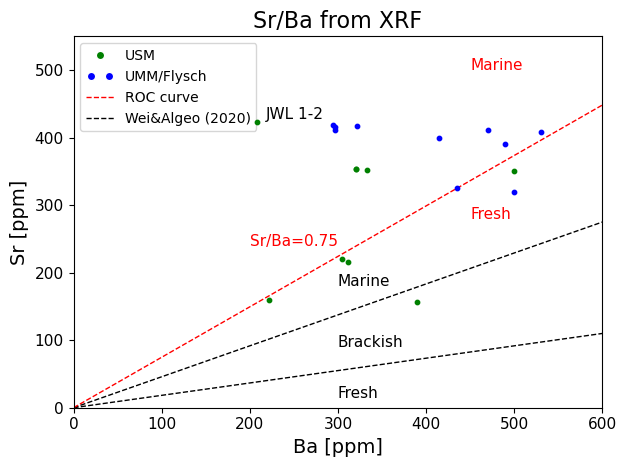

In [3]:
# XRF Results
# Make some overview plots and fit a SVM based regression line.

# Collect those samples that have both Sr and Ba
filter = []
for d in xrf_data.Data:
    ba = val_or_nan(d, 'Ba')
    sr = val_or_nan(d, 'Sr')
    filter.append((ba is np.NAN) or (sr is np.NAN))
filter = np.invert(filter)
sr_data = xrf_data[filter]


# 2. Fit the Model
# First we strip outliers.
xrf_sr_data_outliers = ['JWL 1-2']
ba = xrf_ba[filter]
ba = ba[~np.isin(ba.Sample, xrf_sr_data_outliers)]
bac = ba['Concentration']*1e6
sr = xrf_sr[filter]
sr = sr[~np.isin(sr.Sample, xrf_sr_data_outliers)]
src = sr.Concentration*1e6

# Calculate the 1D ratio feature
ratios = src / bac
sal = [int(salinity[sample_type[rock(i)]] == MARINE) for i in ba.Sample]
# Get false positive and true positive rates for all possible slopes
fpr, tpr, thresholds = roc_curve(sal, ratios)

# Find the threshold slope that maximizes the geometric distance to perfect classification
optimal_idx = np.argmax(tpr - fpr)
sr_xrf_optimal_slope = thresholds[optimal_idx]
print(f"Intuitive optimal slope through origin: {sr_xrf_optimal_slope}")

# Output some data values to be directly imported/updated into the thesis.
with open("../temp/xrf_sr_mean_error_ppm.txt", "w") as f:
    f.write('{:.0f}'.format(sr_data['Data'].apply(lambda inner: inner.loc['Sr', 'concentration_error']).mean() * 1e6))

marker_size = 10
max_x = 600
xx_sr = np.linspace(0, max_x, 10)
# yy = slope * xx + intercept
yy_sr_xrf = sr_xrf_optimal_slope * xx_sr
with open("../temp/sr_ba_roc_line.txt", "w") as f:
    f.write('{:.2f}'.format(sr_xrf_optimal_slope))

fig, ax = plt.subplots()
for idx, row in sr_data.iterrows():
    d = row.Data
    # ax.errorbar( d.loc['Ba'].loc['Concentration']*1e6, d.loc['Sr'].loc['Concentration']*1e6, d.loc['Sr'].loc['concentration_error']*1e6, d.loc['Ba'].loc['concentration_error']*1e6, 
    #             fmt=quality_marker[xrf_quality(row.Compton)], markersize=marker_size,
    #             c=type_color[sample_type[rock(idx)]], elinewidth=1) # pyright: ignore[reportArgumentType]
    ax.scatter( d.loc['Ba'].loc['Concentration']*1e6, d.loc['Sr'].loc['Concentration']*1e6,
                marker='o', s=marker_size, c=type_color[sample_type[rock(idx)]], zorder=10) # pyright: ignore[reportArgumentType]
    if (idx in xrf_sr_data_outliers):
        ax.text(d.loc['Ba'].loc['Concentration']*1e6 + 10, d.loc['Sr'].loc['Concentration']*1e6+5,  idx)

# Boundary fresh/brackisch from Wei, 2020
ax.plot(np.linspace(0, max_x, 10), 0.2*np.linspace(0, 550, 10), linestyle='--', linewidth=1, color='black')
# Boundary brackisch/marine from Wei, 2020
ax.plot(np.linspace(0, max_x, 10), 0.5*np.linspace(0, 550, 10) , linestyle='--', linewidth=1, color='black')
ax.text(300, 15, 'Fresh', color='black')
ax.text(300, 90, 'Brackish', color='black')
ax.text(300, 180, 'Marine', color='black')

ax.plot(xx_sr, yy_sr_xrf, linestyle='--', linewidth=1, color='red')
ax.text(200, 200*sr_xrf_optimal_slope+90, f'Sr/Ba={sr_xrf_optimal_slope:.2f}', color='red')
ax.text(450, 280, 'Fresh', color='red')
ax.text(450, 500, 'Marine', color='red')


ax.set(xlabel='Ba [ppm]', ylabel='Sr [ppm]', title='Sr/Ba from XRF', xlim=(0,max_x), ylim=(0,550))

# Make the custom legend
legend_handles = [
                   (Line2D([0], [0], marker='o', color='w', label=USM, markerfacecolor=type_color[USM], markersize=marker_size-4)),
                   (Line2D([0], [0], marker='o', color='w', label=UMM, markerfacecolor=type_color[UMM], markersize=marker_size-4), 
                    Line2D([0], [0], marker='o', color='w', label=FLYSCH, markerfacecolor=type_color[FLYSCH], markersize=marker_size-4)),
                   (Line2D([0], [0], color='red', label='ROC curve', lw=1, ls='--'), ),
                   (Line2D([0], [0], color='black', label='Wei/Algeo, 2020', lw=1, ls='--'), ),
                   ]
legend_labels = [
    USM,
    '{}/{}'.format(UMM, FLYSCH),
    'ROC curve',
    'Wei&Algeo (2020)',
]
ax.legend(handles=legend_handles, labels=legend_labels, handler_map={(tuple): HandlerTuple(ndivide=None, pad=0.5)})
plt.tight_layout()
plt.savefig('../img/xrf_sr_ba.png', dpi=300)



Intuitive optimal slope through origin: 1.570024657827967


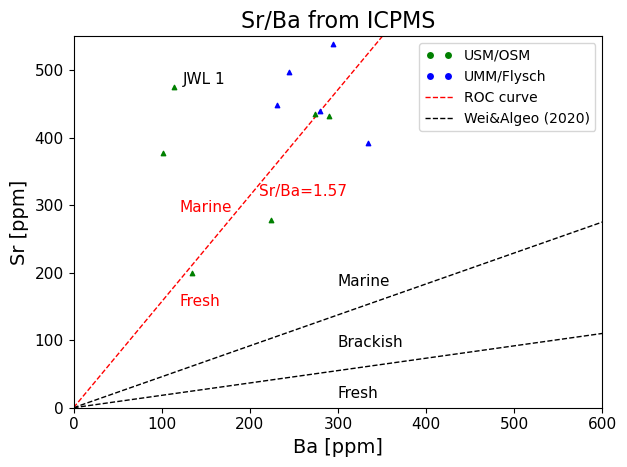

In [4]:
# ICMPS Results
# Make some overview plots and fit a SVM based regression line.

# 2. Fit the Model
# First we strip outliers. Different labels from XRF/ICPMS. JWL 7 is the the OSM sample
sr_data_outliers = ['JWL 1']
strip_samples = ['BCR2']
icp = icpms[~np.isin(icpms.Sample, strip_samples)]
ficp = icp[~np.isin(icp.Sample, sr_data_outliers)]

# Calculate the 1D ratio feature
ratios = ficp['Sr [ppm]'] / ficp['Ba [ppm]']
sal = [int(salinity[sample_type[rock(i)]] == MARINE) for i in ficp.Sample]
# Get false positive and true positive rates for all possible slopes
fpr, tpr, thresholds = roc_curve(sal, ratios)

# Find the threshold slope that maximizes the geometric distance to perfect classification
optimal_idx = np.argmax(tpr - fpr)
icpms_sr_optimal_slope = thresholds[optimal_idx]
print(f"Intuitive optimal slope through origin: {icpms_sr_optimal_slope}")

marker_size = 10
max_x = 600
xx_sr = np.linspace(0, max_x, 10)
yy_sr = icpms_sr_optimal_slope * xx_sr 
with open("../temp/icpms_sr_ba_roc_line.txt", "w") as f:
    f.write('{:.2f}'.format(icpms_sr_optimal_slope))


fig, ax = plt.subplots()
for idx, row in icpms.iterrows():
    ax.scatter( row['Ba [ppm]'], row['Sr [ppm]'], marker='^', s=marker_size,
                c=type_color[sample_type[rock(row.Sample)]], zorder=10) # pyright: ignore[reportArgumentType]
    if (row.Sample in sr_data_outliers):
        ax.text(row['Ba [ppm]'] + 10, row['Sr [ppm]']+5,  row.Sample)
# Boundary fresh/brackisch from Wei, 2020
ax.plot(np.linspace(0, max_x, 10), 0.2*np.linspace(0, 550, 10), linestyle='--', linewidth=1, color='black')
# Boundary brackisch/marine from Wei, 2020
ax.plot(np.linspace(0, max_x, 10), 0.5*np.linspace(0, 550, 10) , linestyle='--', linewidth=1, color='black')
ax.text(300, 15, 'Fresh', color='black')
ax.text(300, 90, 'Brackish', color='black')
ax.text(300, 180, 'Marine', color='black')

# ax.plot(xx, yy, linestyle='--', linewidth=1, color='red')
ax.plot(xx_sr, yy_sr, linestyle='--', linewidth=1, color='red')
ax.text(200+10, 200*icpms_sr_optimal_slope, f'Sr/Ba={icpms_sr_optimal_slope:.2f}', color='red')
ax.text(120, 150, 'Fresh', color='red')
ax.text(120, 290, 'Marine', color='red')


ax.set(xlabel='Ba [ppm]', ylabel='Sr [ppm]', title='Sr/Ba from ICPMS', xlim=(0,max_x), ylim=(0,550))

# Make the custom legend
legend_handles = [
                   (Line2D([0], [0], marker='o', color='w', label=USM, markerfacecolor=type_color[USM], markersize=marker_size-4), 
                    Line2D([0], [0], marker='o', color='w', label=OSM, markerfacecolor=type_color[OSM], markersize=marker_size-4)),
                   (Line2D([0], [0], marker='o', color='w', label=UMM, markerfacecolor=type_color[UMM], markersize=marker_size-4), 
                    Line2D([0], [0], marker='o', color='w', label=FLYSCH, markerfacecolor=type_color[FLYSCH], markersize=marker_size-4)),
                   (Line2D([0], [0], color='red', label='ROC curve', lw=1, ls='--'), ),
                   (Line2D([0], [0], color='black', label='Wei/Algeo, 2020', lw=1, ls='--'), ),
                   ]
legend_labels = [
    '{}/{}'.format(USM, OSM),
    '{}/{}'.format(UMM, FLYSCH),
    'ROC curve',
    'Wei&Algeo (2020)',
]
ax.legend(handles=legend_handles, labels=legend_labels, handler_map={(tuple): HandlerTuple(ndivide=None, pad=0.5)})
plt.tight_layout()
plt.savefig('../img/icpms_sr_ba.png', dpi=300)



Text(0.5, 1.0, '2-Cluster KMeans Clusters')

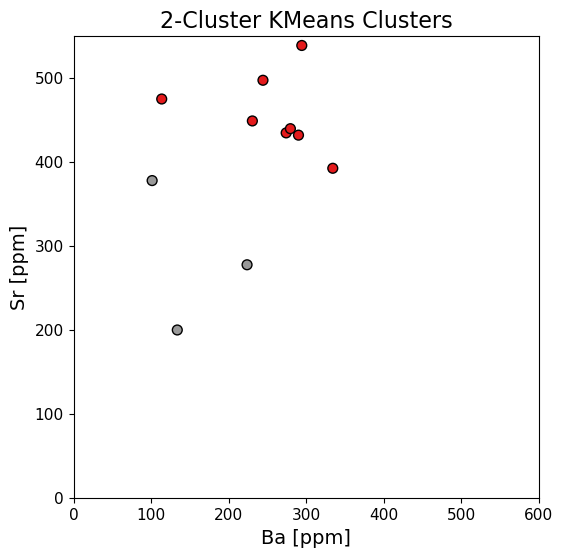

In [5]:
# Try k-means clustering

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from scipy.spatial import Voronoi, voronoi_plot_2d

# 1. Create a dummy dataframe with columns 'A' and 'B'
np.random.seed(42)

X = icp[['Ba [ppm]', 'Sr [ppm]']].values

# 2. Fit the KMeans Model
n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, init=[[200, 500], [200, 350]])
labels = kmeans.fit_predict(X)
# centroids = kmeans.cluster_centers_

# # 3. Create a mesh grid to map the 2 halves
# x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
# y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
# xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# # Predict the cluster for every point on the background grid
# Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# # 4. Plotting
fig, ax = plt.subplots(figsize=(6, 6))

# # Fill background with the two regions
# ax.imshow(Z, interpolation='nearest',
#           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
#           cmap='Pastel1', aspect='auto', origin='lower', alpha=0.6)

color = ['blue' if labels[i] == 1 else 'gree' for i in range(len(labels))]
# # Overlay data points and centroids
ax.scatter(icp['Ba [ppm]'], icp['Sr [ppm]'], c=labels, cmap='Set1', edgecolor='k', s=50, zorder=3)
# ax.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='black', label='Centroids', zorder=4)
ax.set_xlim(0, 600)
ax.set_ylim(0, 550)
ax.set_xlabel('Ba [ppm]')
ax.set_ylabel('Sr [ppm]')
ax.set_title('2-Cluster KMeans Clusters')
# plt.show()

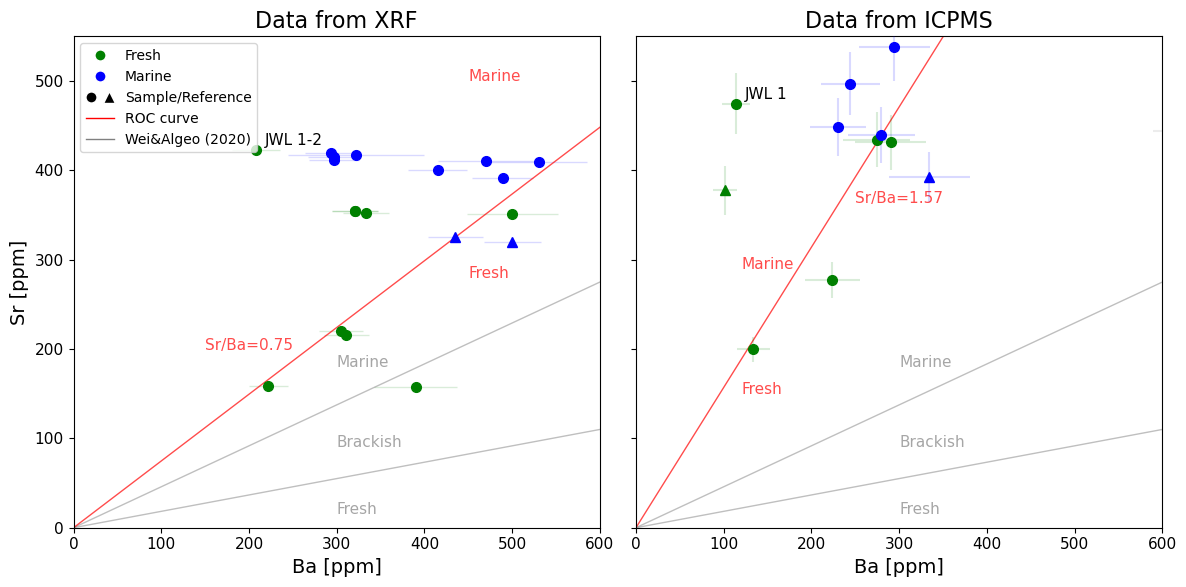

In [6]:
# Combined Sr/Ba plot

marker_size=7
max_x = 600
fig, axs = plt.subplots(1,2, figsize=(12,6), sharey=True)
for idx, row in sr_data.iterrows():
    d = row.Data
    base_color = type_color[sample_type[rock(idx)]]
    error_bar_color = mcolors.to_rgba(base_color, alpha=0.15)

    axs[0].errorbar( d.loc['Ba'].loc['Concentration']*1e6, d.loc['Sr'].loc['Concentration']*1e6, 
                    yerr=d.loc['Sr'].loc['concentration_error']*1e6, xerr=d.loc['Ba'].loc['concentration_error']*1e6, 
                marker=type_symbol[sample_type[rock(idx)]], markersize=marker_size,
                c=type_color[sample_type[rock(idx)]], elinewidth=1, ecolor=error_bar_color) # pyright: ignore[reportArgumentType]
    # axs[0].scatter( d.loc['Ba'].loc['Concentration']*1e6, d.loc['Sr'].loc['Concentration']*1e6,
    #             marker='o', s=marker_size, c=type_color[sample_type[rock(idx)]], zorder=10) # pyright: ignore[reportArgumentType]
    if (idx in xrf_sr_data_outliers):
        axs[0].text(d.loc['Ba'].loc['Concentration']*1e6 + 10, d.loc['Sr'].loc['Concentration']*1e6+5,  idx)

# Boundary fresh/brackisch from Wei, 2020
axs[0].plot(np.linspace(0, max_x, 10), 0.2*np.linspace(0, 550, 10), linestyle='-', linewidth=1, color='gray', alpha=0.5)
# Boundary brackisch/marine from Wei, 2020
axs[0].plot(np.linspace(0, max_x, 10), 0.5*np.linspace(0, 550, 10) , linestyle='-', linewidth=1, color='gray', alpha=0.5)
axs[0].text(300, 15, 'Fresh', color='gray', alpha=0.7)
axs[0].text(300, 90, 'Brackish', color='gray', alpha=0.7)
axs[0].text(300, 180, 'Marine', color='gray', alpha=0.7)

axs[0].plot(xx_sr, yy_sr_xrf, linestyle='-', linewidth=1, color='red', alpha=0.7)
axs[0].text(150, 200*sr_xrf_optimal_slope+50, f'Sr/Ba={sr_xrf_optimal_slope:.2f}', color='red', alpha=0.7)
axs[0].text(450, 280, 'Fresh', color='red', alpha=0.7)
axs[0].text(450, 500, 'Marine', color='red', alpha=0.7)

axs[0].set(xlabel='Ba [ppm]', ylabel='Sr [ppm]', title='Data from XRF', xlim=(0,max_x), ylim=(0,550))

# Make the custom legend
legend_handles = [
                   Line2D([0], [0], marker='o', color='w', label=salinity[USM], markerfacecolor=type_color[USM], markersize=marker_size+1),
                   Line2D([0], [0], marker='o', color='w', label=salinity[UMM], markerfacecolor=type_color[UMM], markersize=marker_size+1), 
                   (Line2D([0], [0], marker=type_symbol[USM], color='w', label=SAMPLE, markerfacecolor='black', markersize=marker_size+1), 
                   Line2D([0], [0], marker=type_symbol[OSM], color='w', label=STANDARD, markerfacecolor='black', markersize=marker_size+1)),
                   (Line2D([0], [0], color='red', label='ROC curve', lw=1, ls='-'), ),
                   (Line2D([0], [0], color='gray', label='Wei/Algeo, 2020', lw=1, ls='-'), ),
                   ]
legend_labels = [
    FRESH,
    MARINE,
    '{}/{}'.format(SAMPLE, STANDARD),
    'ROC curve',
    'Wei&Algeo (2020)',
]
axs[0].legend(handles=legend_handles, labels=legend_labels, handler_map={(tuple): HandlerTuple(ndivide=None, pad=0.5)}, loc='upper left')

for idx, row in icpms.iterrows():
    base_color = type_color[sample_type[rock(row.Sample)]]
    error_bar_color = mcolors.to_rgba(base_color, alpha=0.15)
    axs[1].errorbar(row['Ba [ppm]'], row['Sr [ppm]'], xerr=row['Ba [ppm]']*icpms_uncertainties.loc['138 Ba']['Uncertainty'], yerr=row['Sr [ppm]']*icpms_uncertainties.loc['88 Sr']['Uncertainty'],
                marker=type_symbol[sample_type[rock(row.Sample)]], markersize=marker_size, c=type_color[sample_type[rock(row.Sample)]], zorder=10,
                ecolor=error_bar_color) # pyright: ignore[reportArgumentType]
    # axs[1].scatter( row['Ba [ppm]'], row['Sr [ppm]'], marker='o', s=marker_size,
    #             c=type_color[sample_type[rock(row.Sample)]], zorder=10) # pyright: ignore[reportArgumentType]
    if (row.Sample in sr_data_outliers):
        axs[1].text(row['Ba [ppm]'] + 10, row['Sr [ppm]']+5,  row.Sample)

# Boundary fresh/brackisch from Wei, 2020
axs[1].plot(np.linspace(0, max_x, 10), 0.2*np.linspace(0, 550, 10), linestyle='-', linewidth=1, color='gray', alpha=0.5)
# Boundary brackisch/marine from Wei, 2020
axs[1].plot(np.linspace(0, max_x, 10), 0.5*np.linspace(0, 550, 10) , linestyle='-', linewidth=1, color='gray', alpha=0.5)
axs[1].text(300, 15, 'Fresh', color='gray', alpha=0.7)
axs[1].text(300, 90, 'Brackish', color='gray', alpha=0.7)
axs[1].text(300, 180, 'Marine', color='gray', alpha=0.7)

# ax.plot(xx, yy, linestyle='--', linewidth=1, color='red')
axs[1].plot(xx_sr, yy_sr, linestyle='-', linewidth=1, color='red', alpha=0.7)
axs[1].text(200+50, 200*icpms_sr_optimal_slope+50, f'Sr/Ba={icpms_sr_optimal_slope:.2f}', color='red', alpha=0.7)
axs[1].text(120, 150, 'Fresh', color='red', alpha=0.7)
axs[1].text(120, 290, 'Marine', color='red', alpha=0.7)

axs[1].set(xlabel='Ba [ppm]', title='Data from ICPMS', xlim=(0,max_x), ylim=(0,550))


plt.tight_layout()
plt.savefig('../img/sr_ba_combined.png', dpi=300)

In [7]:
# TOOD: Figure out if we can easily center the tables.
NAN = '---'

# Prepare and output data tables
def format_nan(data, num_format_string):
    length:int = len(data)
    res = [''] * length
    for i, d in enumerate(data):
        if np.isnan(d):
            res[i] = NAN
        else:
            res[i] = num_format_string.format(d)
    return np.array(res)


SR_BA = pd.DataFrame()
SR_BA['Sample'] = xrf_sr.Sample
SR_BA['Sr [ppm]'] = ['{} $\\pm$ {}'.format(c, e) for (c, e) in zip(format_nan(xrf_sr.Concentration * 1e6, '{:.0f}'), format_nan(xrf_sr.Error * 1e6, '{:.0f}'))]
ba_format = [''] * len(xrf_ba)
for i, (c, e) in enumerate(zip(xrf_ba.Concentration * 1e6, xrf_ba.Error * 1e6)):
    if not np.isnan(c) and not np.isnan(e):
        ba_format[i] = '{:.0f} $\\pm$ {:.0f}'.format(c, e)
    else:
        ba_format[i] = NAN
SR_BA['Ba [ppm]'] = ba_format
srba = [''] * len(xrf_ba)
for i, (c, e) in enumerate(zip(xrf_sr.Concentration * 1e6, xrf_ba.Concentration * 1e6)):
    if not np.isnan(c) and not np.isnan(e):
        srba[i] = '{:.2f}'.format(c/e)
    else:
        srba[i] = NAN
SR_BA['Sr/Ba'] = srba
compton = ['{:.2f}'.format(c) for c in xrf_data['Compton']]
SR_BA['Compton ratio'] = compton
SR_BA.style.hide(axis='index').format_index(lambda x: f"\\textbf{{{x}}}", axis='columns').to_latex('../temp/sr-ba-table.txt', column_format='lrrrr', hrules=True)

# Same outpus for ICPMS data
SR_BA_ICPMS = pd.DataFrame()
SR_BA_ICPMS['Sample'] = icpms.Sample
SR_BA_ICPMS['Sr [ppm]'] = ['{} $\\pm$ {}'.format(c, e) for (c, e) in zip(format_nan(icpms['Sr [ppm]'], '{:.0f}'), format_nan(icpms['Sr [ppm]']*icpms_uncertainties.loc['88 Sr']['Uncertainty'], '{:.0f}'))]
SR_BA_ICPMS['Ba [ppm]'] = ['{} $\\pm$ {}'.format(c, e) for (c, e) in zip(format_nan(icpms['Ba [ppm]'], '{:.0f}'), format_nan(icpms['Ba [ppm]']*icpms_uncertainties.loc['138 Ba']['Uncertainty'], '{:.0f}'))]
srba_icpms = [''] * len(icpms)
for i, (c, e) in enumerate(zip(icpms['Sr [ppm]'], icpms['Ba [ppm]'])):
    if not np.isnan(c) and not np.isnan(e):
        srba_icpms[i] = '{:.2f}'.format(c/e)
    else:
        srba_icpms[i] = NAN
SR_BA_ICPMS['Sr/Ba'] = srba_icpms
SR_BA_ICPMS.style.hide(axis='index').format_index(lambda x: f"\\textbf{{{x}}}", axis='columns').to_latex('../temp/sr-ba-icpms-table.txt', column_format='lrrrr', hrules=True)

In [8]:
# Export S/TOC data

STOC = pd.DataFrame({
    'Sample': toc_all['Sample'],    
})
STOC['S [ppm]'] = ['{} $\\pm$ {}'.format(c, e) for (c, e) in zip(format_nan(toc_all['S'] * 1e6, '{:.0f}'), format_nan(toc_all['S Error'] * 1e6, '{:.0f}'))]
STOC['TOC [ppm]'] = ['{}'.format(c) for c in format_nan(toc_all['C  [%]'] * 1e4, '{:.0f}')]
stoc = [''] * len(toc_all)
for i, (c, e) in enumerate(zip(toc_all['S'] * 1e6, toc_all['C  [%]']*1e4)):
    if not np.isnan(c) and not np.isnan(e):
        stoc[i] = '{:.2f}'.format(c/e)
    else:
        stoc[i] = NAN
# TODO: do correct error propagation
STOC['S/TOC'] = stoc
STOC.style.hide(axis='index').format_index(lambda x: f"\\textbf{{{x}}}", axis='columns').to_latex('../temp/s-toc-table.txt', column_format='lrrr', hrules=True)

# S(HR from ICPMS)

#Drop BCR2 standard
icpms_flt = icpms[~np.isin(icpms.Sample, ['BCR2'])]
S_HR_ICPMS = pd.DataFrame({
    'Sample': icpms_flt.Sample,
})
S_HR_ICPMS['S [ppm]'] = ['{} $\\pm$ {}'.format(c, e) for (c, e) in zip(format_nan(icpms_flt['S (HR) [pm]']*1e3, '{:.0f}'), format_nan(icpms_flt['S (HR) [pm]']*icpms_uncertainties.loc['32 S']['Uncertainty']*1e3, '{:.0f}'))]
S_HR_ICPMS['TOC [ppm]'] = ['{}'.format(c) for c in format_nan(toc_all['C  [%]'] * 1e4, '{:.0f}')]
hr = [''] * len(icpms_flt)
for i, (c, e) in enumerate(zip(icpms_flt['S (HR) [pm]'], toc_all['C  [%]'])):
    if not np.isnan(c) and not np.isnan(e):
        hr[i] = '{:.2f}'.format((c*1e3)/(e*1e4))
    else:
        hr[i] = NAN
S_HR_ICPMS['S/HR'] = hr
S_HR_ICPMS.style.hide(axis='index').format_index(lambda x: f"\\textbf{{{x}}}", axis='columns').to_latex('../temp/s-hr-icpms-table.txt', column_format='lrrr', hrules=True)

Intuitive optimal slope through origin: 0.0732158860996628


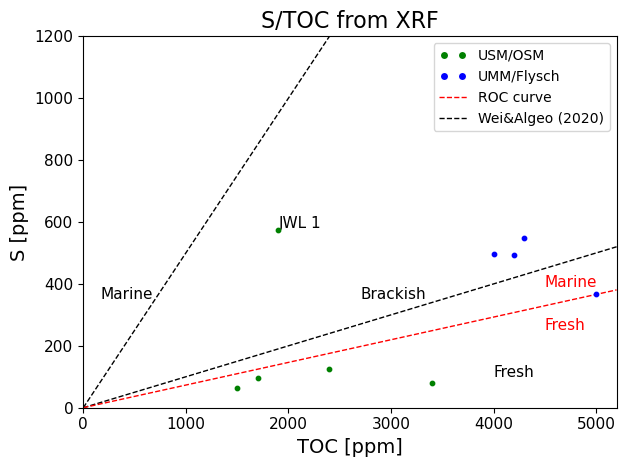

In [9]:
# XRF TOC plots and analysis 

# 2. Fit the Model
filter = np.invert(np.isnan(toc_all['C  [%]']))
t = toc_all[filter]

# Remove JWL 1 for fitting
toc_data_outliers = ['JWL 1']
tt = t[~np.isin(t.Sample, toc_data_outliers)]

# Calculate the 1D ratio feature
ratios = (tt['S']*1e6) / (tt['C  [%]']*1e4)
sal = [int(salinity[sample_type[rock(i)]] == MARINE) for i in tt.Sample]
# Get false positive and true positive rates for all possible slopes
fpr, tpr, thresholds = roc_curve(sal, ratios)

# Find the threshold slope that maximizes the geometric distance to perfect classification
optimal_idx = np.argmax(tpr - fpr)
xrf_toc_optimal_slope = thresholds[optimal_idx]
print(f"Intuitive optimal slope through origin: {xrf_toc_optimal_slope}")

max_x = 5200
xx_toc = np.linspace(0, max_x, 10)
yy_toc_xrf = xrf_toc_optimal_slope * xx_toc
with open("../temp/xrf_toc_roc_line.txt", "w") as f:
    f.write('{:.2f}'.format(xrf_toc_optimal_slope))

marker_size=10
fig, ax =  plt.subplots()
for idx, row in t.iterrows():
    # ax.errorbar(row['C  [%]']*1e4, row['S']*1e6, xerr=0, yerr=row['S Error']*1e6, fmt='o', markersize=marker_size,
    #             c=type_color[sample_type[row['Sample']]], elinewidth=1) # pyright: ignore[reportArgumentType]
    ax.scatter(row['C  [%]']*1e4, row['S']*1e6, marker='o', s=marker_size,
                c=type_color[sample_type[row['Sample']]], zorder=10) # pyright: ignore[reportArgumentType]
    if row['Name'] in toc_data_outliers:
        ax.text(row['C  [%]']*1e4 + 10, row['S']*1e6+5,  row['Name'])

# Boundary fresh/brackisch from Wei, 2020
ax.plot(np.linspace(0, max_x, 10), 0.1*np.linspace(0, max_x, 10), linestyle='--', linewidth=1, color='black')
# Boundary brackisch/marine from Wei, 2020
ax.plot(np.linspace(0, max_x, 10), 0.5*np.linspace(0, max_x, 10) , linestyle='--', linewidth=1, color='black')
ax.text(4000, 100, 'Fresh', color='black')
ax.text(2700, 350, 'Brackish', color='black')
ax.text(170, 350, 'Marine', color='black')

ax.plot(xx_toc, yy_toc_xrf, linestyle='--', linewidth=1, color='red')
ax.text(4500, 250, 'Fresh', color='red')
ax.text(4500, 390, 'Marine', color='red')

ax.set(xlabel='TOC [ppm]', ylabel='S [ppm]', title='S/TOC from XRF', xlim=(0,max_x), ylim=(0,1200))

# Make the custom legend
legend_handles = [
                   (Line2D([0], [0], marker='o', color='w', label=USM, markerfacecolor=type_color[USM], markersize=marker_size-4), 
                    Line2D([0], [0], marker='o', color='w', label=OSM, markerfacecolor=type_color[OSM], markersize=marker_size-4)),
                   (Line2D([0], [0], marker='o', color='w', label=UMM, markerfacecolor=type_color[UMM], markersize=marker_size-4), 
                    Line2D([0], [0], marker='o', color='w', label=FLYSCH, markerfacecolor=type_color[FLYSCH], markersize=marker_size-4)),
                   (Line2D([0], [0], color='red', label='ROC curve', lw=1, ls='--'), ),
                   (Line2D([0], [0], color='black', label='Wei/Algeo, 2020', lw=1, ls='--'), ),
                   ]
legend_labels = [
    '{}/{}'.format(USM, OSM),
    '{}/{}'.format(UMM, FLYSCH),
    'ROC curve',
    'Wei&Algeo (2020)',
]
ax.legend(handles=legend_handles, labels=legend_labels, handler_map={(tuple): HandlerTuple(ndivide=None, pad=0.5)}, loc='upper right')
plt.tight_layout()
plt.savefig('../img/xrf_toc_s.png', dpi=300)


Intuitive optimal slope through origin: 0.184


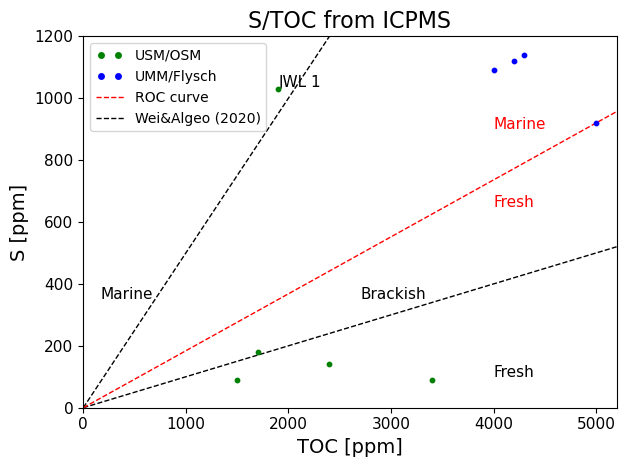

In [10]:
# ICPMS TOC plots and analysis

# 2. Fit the Model
filter = np.invert(np.isnan(toc_all['C  [%]']))
t = toc_all[filter]
toc_data_outliers = ['JWL 1']
toc_missing_data = ['JWL 5', 'JWL 8']
tt = t[~np.isin(t.Sample, toc_missing_data)]
ftt = t[~np.isin(t.Sample, toc_data_outliers)]
ftt = ftt.drop('Name', axis=1)

# We need to remove JW: 5 and 8 from ICMPS, because TOC isn't complete.
strip_outliers = ['JWL 1']
strip_samples = ['BCR2']
icp = icpms[~np.isin(icpms.Sample, strip_samples)]
icp = icp[~np.isin(icp.Sample, toc_missing_data)]
fdata = pd.merge(tt, icp, on='Sample')

regress_data = fdata[~np.isin(icp.Sample, strip_outliers)]


# Calculate the 1D ratio feature
ratios = regress_data['S (HR) [pm]'] / (regress_data['C  [%]'] * 10)
sal = [int(salinity[sample_type[rock(i)]] == MARINE) for i in regress_data.Sample]
# Get false positive and true positive rates for all possible slopes
fpr, tpr, thresholds = roc_curve(sal, ratios)

# Find the threshold slope that maximizes the geometric distance to perfect classification
optimal_idx = np.argmax(tpr - fpr)
icpms_toc_optimal_slope = thresholds[optimal_idx]
print(f"Intuitive optimal slope through origin: {icpms_toc_optimal_slope}")

max_x = 5200
xx_toc = np.linspace(0, max_x, 10)
yy_toc = icpms_toc_optimal_slope * xx_toc
with open("../temp/icpms_toc_roc_line.txt", "w") as f:
    f.write('{:.2f}'.format(icpms_toc_optimal_slope))

marker_size=10
fig, ax =  plt.subplots()
# for idx, row in t.iterrows():
    # ax.errorbar(row['C  [%]']*1e4, row['S']*1e6, xerr=0, yerr=row['S Error']*1e6, fmt='o', markersize=marker_size,
    #             c=type_color[sample_type[row['Sample']]], elinewidth=1) # pyright: ignore[reportArgumentType]
for idx, row in fdata.iterrows():
    ax.scatter(row['C  [%]']*1e4, row['S (HR) [pm]']*1e3 , marker='o', s=marker_size,
                    c=type_color[sample_type[row['Sample']]], zorder=10) # pyright: ignore[reportArgumentType]
    if row['Sample'] in strip_outliers:
        ax.text(row['C  [%]']*1e4 + 10, row['S (HR) [pm]']*1e3+5,  row['Sample'])

# Boundary fresh/brackisch from Wei, 2020
ax.plot(np.linspace(0, max_x, 10), 0.1*np.linspace(0, max_x, 10), linestyle='--', linewidth=1, color='black')
# Boundary brackisch/marine from Wei, 2020
ax.plot(np.linspace(0, max_x, 10), 0.5*np.linspace(0, max_x, 10) , linestyle='--', linewidth=1, color='black')
ax.text(4000, 100, 'Fresh', color='black')
ax.text(2700, 350, 'Brackish', color='black')
ax.text(170, 350, 'Marine', color='black')

ax.plot(xx_toc, yy_toc, linestyle='--', linewidth=1, color='red')
ax.text(4000, 650, 'Fresh', color='red')
ax.text(4000, 900, 'Marine', color='red')

ax.set(xlabel='TOC [ppm]', ylabel='S [ppm]', title='S/TOC from ICPMS', xlim=(0,max_x), ylim=(0,1200))

# Make the custom legend
legend_handles = [
                   (Line2D([0], [0], marker='o', color='w', label=USM, markerfacecolor=type_color[USM], markersize=marker_size-4), 
                    Line2D([0], [0], marker='o', color='w', label=OSM, markerfacecolor=type_color[OSM], markersize=marker_size-4)),
                   (Line2D([0], [0], marker='o', color='w', label=UMM, markerfacecolor=type_color[UMM], markersize=marker_size-4), 
                    Line2D([0], [0], marker='o', color='w', label=FLYSCH, markerfacecolor=type_color[FLYSCH], markersize=marker_size-4)),
                   (Line2D([0], [0], color='red', label='ROC curve', lw=1, ls='--'), ),
                   (Line2D([0], [0], color='black', label='Wei/Algeo, 2020', lw=1, ls='--'), ),
                   ]
legend_labels = [
    '{}/{}'.format(USM, OSM),
    '{}/{}'.format(UMM, FLYSCH),
    'ROC curve',
    'Wei&Algeo (2020)',
]
ax.legend(handles=legend_handles, labels=legend_labels, handler_map={(tuple): HandlerTuple(ndivide=None, pad=0.5)}, loc='upper left')
plt.tight_layout()
plt.savefig('../img/icpms_toc_s.png', dpi=300)


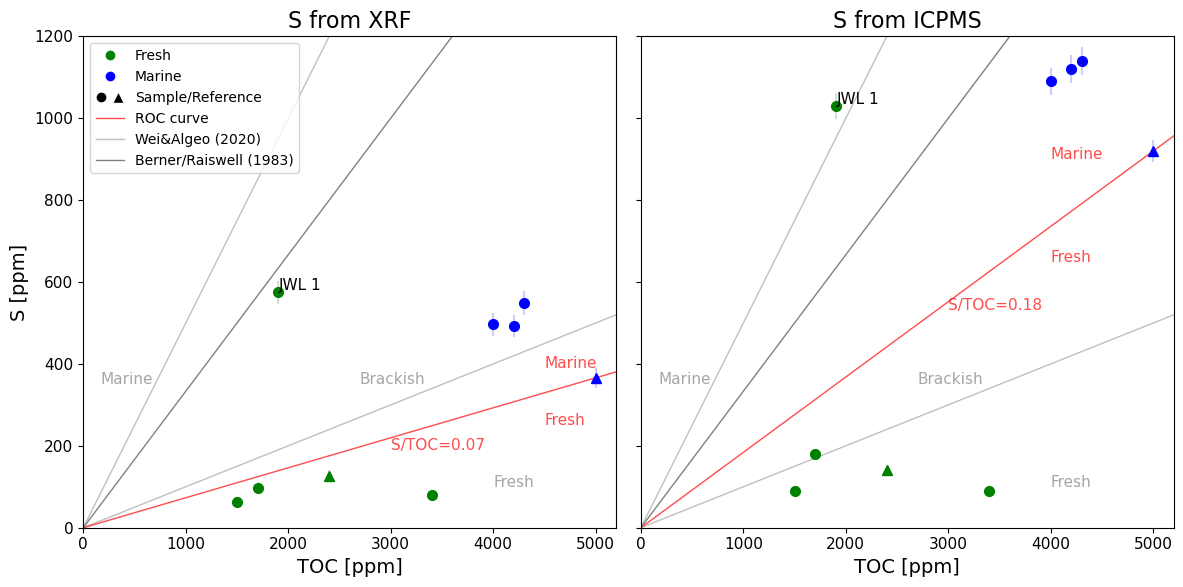

In [11]:
# Combined plot for S/TOC

to_plot = zip(icpms.Sample, icp['S (MR) [pm]'], tt['C  [%]'] * 1e4)
max_x = 5200
marker_size=7
alpha = 0.2

fig, axs =  plt.subplots(1,2, figsize=(12,6), sharey=True)
for idx, row in t.iterrows():
    base_color = type_color[sample_type[row['Sample']]]
    err_color = mcolors.to_rgba(base_color, alpha=alpha)
    axs[0].errorbar(row['C  [%]']*1e4, row['S']*1e6, xerr=0, yerr=row['S Error']*1e6, fmt=type_symbol[sample_type[row['Sample']]], markersize=marker_size,
                c=type_color[sample_type[row['Sample']]], elinewidth=1.5, ecolor=err_color) # pyright: ignore[reportArgumentType]
    # axs[0].scatter(row['C  [%]']*1e4, row['S']*1e6, marker='o', s=marker_size,
    #             c=type_color[sample_type[row['Sample']]], zorder=10) # pyright: ignore[reportArgumentType]
    if row['Name'] in toc_data_outliers:
        axs[0].text(row['C  [%]']*1e4 + 10, row['S']*1e6+5,  row['Name'])

# Boundary fresh/brackisch from Wei, 2020
axs[0].plot(np.linspace(0, max_x, 10), 0.1*np.linspace(0, max_x, 10), linestyle='-', linewidth=1, color='gray', alpha=0.5)
# Boundary brackisch/marine from Wei, 2020
axs[0].plot(np.linspace(0, max_x, 10), 0.5*np.linspace(0, max_x, 10) , linestyle='-', linewidth=1, color='gray', alpha=0.5)
axs[0].text(4000, 100, 'Fresh', color='gray', alpha=0.7)
axs[0].text(2700, 350, 'Brackish', color='gray', alpha=0.7)
axs[0].text(170, 350, 'Marine', color='gray', alpha=0.7)

axs[0].plot(xx_toc, yy_toc_xrf, linestyle='-', linewidth=1, color='red', alpha=0.7)
axs[0].text(3000, 3000*xrf_toc_optimal_slope-30, f'S/TOC={xrf_toc_optimal_slope:.2f}', color='red', alpha=0.7)
axs[0].text(4500, 250, 'Fresh', color='red', alpha=0.7)
axs[0].text(4500, 390, 'Marine', color='red', alpha=0.7)

axs[0].set(xlabel='TOC [ppm]', ylabel='S [ppm]', title='S from XRF', xlim=(0,max_x), ylim=(0,1200))

axs[0].plot(xx_toc, 1/3*xx_toc, linestyle='-', linewidth=1, color='gray')
# axs[0].plot(xx_toc, 1/10*xx_toc, linestyle='--', linewidth=1, color='blue')

# Make the custom legend
legend_handles = [
                   Line2D([0], [0], marker='o', color='w', label=salinity[USM], markerfacecolor=type_color[USM], markersize=marker_size+1),
                   Line2D([0], [0], marker='o', color='w', label=salinity[UMM], markerfacecolor=type_color[UMM], markersize=marker_size+1), 
                   (Line2D([0], [0], marker=type_symbol[USM], color='w', label=SAMPLE, markerfacecolor='black', markersize=marker_size+1), 
                   Line2D([0], [0], marker=type_symbol[OSM], color='w', label=STANDARD, markerfacecolor='black', markersize=marker_size+1)),
                   Line2D([0], [0], color='red', label='ROC curve', lw=1, ls='-', alpha=0.7),
                   Line2D([0], [0], color='gray', label='Wei/Algeo, 2020', lw=1, ls='-', alpha=0.5),
                   Line2D([0], [0], color='gray', label='Berner/Raiswell, 1983', lw=1, ls='-'),
                   ]
legend_labels = [
    FRESH,
    MARINE,
    '{}/{}'.format(SAMPLE, STANDARD),
    'ROC curve',
    'Wei&Algeo (2020)',
    'Berner/Raiswell (1983)',
]
axs[0].legend(handles=legend_handles, labels=legend_labels, handler_map={(tuple): HandlerTuple(ndivide=None, pad=0.5)}, loc='upper left')

for idx, row in fdata.iterrows():
    base_color = type_color[sample_type[row['Sample']]]
    err_color = mcolors.to_rgba(base_color, alpha=alpha)
    axs[1].errorbar(row['C  [%]']*1e4, row['S (HR) [pm]']*1e3, 
                    xerr=0, yerr=row['S (HR) [pm]']*1e3*icpms_uncertainties.loc['32 S']['Uncertainty'], 
                    fmt=type_symbol[sample_type[row['Sample']]], markersize=marker_size,
                    c=type_color[sample_type[row['Sample']]], elinewidth=1.5, ecolor=err_color) # pyright: ignore[reportArgumentType]

    # axs[1].scatter(row['C  [%]']*1e4, row['S (HR) [pm]']*1e3 , marker='o', s=marker_size,
    #                 c=type_color[sample_type[row['Sample']]], zorder=10) # pyright: ignore[reportArgumentType]
    if row['Sample'] in strip_outliers:
        axs[1].text(row['C  [%]']*1e4 + 10, row['S (HR) [pm]']*1e3+5,  row['Sample'])


# Boundary fresh/brackisch from Wei, 2020
axs[1].plot(np.linspace(0, max_x, 10), 0.1*np.linspace(0, max_x, 10), linestyle='-', linewidth=1, color='gray', alpha=0.5)
# Boundary brackisch/marine from Wei, 2020
axs[1].plot(np.linspace(0, max_x, 10), 0.5*np.linspace(0, max_x, 10) , linestyle='-', linewidth=1, color='gray', alpha=0.5)
axs[1].text(4000, 100, 'Fresh', color='gray', alpha=0.7)
axs[1].text(2700, 350, 'Brackish', color='gray', alpha=0.7)
axs[1].text(170, 350, 'Marine', color='gray', alpha=0.7)


axs[1].plot(xx_toc, yy_toc, linestyle='-', linewidth=1, color='red', alpha=0.7)
axs[1].text(3000, 3000*icpms_toc_optimal_slope-20, f'S/TOC={icpms_toc_optimal_slope:.2f}', color='red', alpha=0.7)
axs[1].text(4000, 650, 'Fresh', color='red', alpha=0.7)
axs[1].text(4000, 900, 'Marine', color='red', alpha=0.7)
axs[1].set(xlabel='TOC [ppm]', title='S from ICPMS', xlim=(0,max_x), ylim=(0,1200))

axs[1].plot(xx_toc, 1/3*xx_toc, linestyle='-', linewidth=1, color='gray')

plt.tight_layout()
plt.savefig('../img/toc_s_combined.png', dpi=300)

In [12]:
# Compute summary classification table. We use averages when more than one tested sample per rock exists.
def classify(slope, brackish, marine, svm)->tuple[str, str]:
    '''
    sample: (x,y) coordinate tuple of the sample
    brackish: slope of the brackish divider (Wei + Algeo)
    marine: slope of the marine divider (Wei + Algeo)
    svm: slope of the svm divider (our fit)

    The slopes are enough, because all lines go through the origin.

    Return M (marine), B (brackish), F (freshwater) for both wei and us.
    Return -- if the slope can't be determined.
    '''
    if np.isnan(slope):
        return ('--', '--')
    w = 'M'
    if slope <= marine:
        w = 'B'
    if slope <= brackish:
        w = 'F'
    u = 'M'
    if slope <= svm:
        u = 'F'
    return (w, u)


# We need as inputs:
#  * Slopes for our fit curves
# !!!! We have named variables from the cells above !!!

#  * Slopes for Wei curves
wei_sr_brackish = 0.5  # Marine/brackish 
wei_sr_fresh = 0.2 # brackish/fresh
wei_toc_brackish = 0.5 # Marine/brackish
wei_toc_fresh = 0.1 # brackish/fresh

#  * Indexed data columns for the measurements. This data should be fully indexed and have NaNs where appropriate.
tmp_xrf_ba = avg_by_sample(pd.DataFrame({'Sample': xrf_ba['Sample'], 'Concentration': xrf_ba['Concentration']}), 'Concentration')
tmp_xrf_ba.name = 'Ba'
tmp_xrf_sr = avg_by_sample(pd.DataFrame({'Sample': xrf_sr['Sample'], 'Concentration': xrf_sr['Concentration']}), 'Concentration')
tmp_xrf_sr.name = 'Sr'
tmp_xrf_df = tmp_xrf_ba.to_frame().join(tmp_xrf_sr, how='inner')
tmp_xrf_s_df = pd.DataFrame(index=toc_all.Sample)
tmp_xrf_s_df['S'] = toc_all['S'].values
tmp_xrf_df = tmp_xrf_df.join(tmp_xrf_s_df, how='outer')
tmp_toc = toc_all.copy()
tmp_toc.index = tmp_toc.Name # type: ignore
tmp_icpms = icpms[icpms.Sample != 'BCR2']
tmp_icpms.index = tmp_icpms.Sample

# Ratios for the trace element pairs.
xrf_sr_ba_ratio = tmp_xrf_df['Sr']/tmp_xrf_df['Ba']  # Both are in ppm, so scaling doesn't matter
xrf_toc_ratio = (tmp_xrf_df['S']*1e6)/(tmp_toc['C  [%]']*1e4) # S is in PPM, C in %
icpms_sr_ba_ratio = tmp_icpms['Sr [ppm]']/tmp_icpms['Ba [ppm]']
icpms_toc_ratio = tmp_icpms['S (HR) [pm]']/(tmp_toc['C  [%]']*10)  # ICPMS S is in permille, C in percent

# Classifications 
xrf_sr_ba_wei, xrf_sr_ba_best = zip(*[classify(r, wei_sr_fresh, wei_sr_brackish, sr_xrf_optimal_slope) for r in xrf_sr_ba_ratio])
xrf_toc_wei, xrf_toc_best = zip(*[classify(r, wei_toc_fresh, wei_toc_brackish, xrf_toc_optimal_slope) for r in xrf_toc_ratio])
# We have to rebuild the index, because the order in the different frames is different.
tmp_df = pd.DataFrame(index=xrf_sr_ba_ratio.index)
tmp_df['XRF_SR_WEI'] = xrf_sr_ba_wei
tmp_df['XRF_SR_BEST'] = xrf_sr_ba_best
tmp_df['XRF_TOC_WEI'] = xrf_toc_wei
tmp_df['XRF_TOC_BEST'] = xrf_toc_best

icpms_sr_ba_wei, icpms_sr_ba_best = zip(*[classify(r, wei_sr_fresh, wei_sr_brackish, icpms_sr_optimal_slope) for r in icpms_sr_ba_ratio])
icpms_toc_wei, icpms_toc_best = zip(*[classify(r, wei_toc_fresh, wei_toc_brackish, icpms_toc_optimal_slope) for r in icpms_toc_ratio])
tmp_icp_df = pd.DataFrame(index=icpms_sr_ba_ratio.index)
tmp_icp_df['ICP_SR_WEI'] = icpms_sr_ba_wei
tmp_icp_df['ICP_SR_BEST'] = icpms_sr_ba_best
tmp_icp_df['ICP_TOC_WEI'] = icpms_toc_wei
tmp_icp_df['ICP_TOC_BEST'] = icpms_toc_best

tmp_class = tmp_df.join(tmp_icp_df, how='outer')

# Classifications drawn from UMM, USM, OSM, FLYSCH designation on the geological map.
tmp_map = pd.DataFrame({'Map': ['F', 'F', 'F', 'F', 'F', 'M', 'F', 'M', 'M', 'M', 'M']},
                       index=['JWL 1', 'JWL 2', 'JWL 3', 'JWL 4', 'JWL 5', 'JWL 6', 'JWL 7', 'JWL 8', 'JWL 9', 'JWL 11', 'JWL 12' ])
tmp_class = tmp_class.join(tmp_map)
tmp_class.sort_index(inplace=True)

# XRF data
# Make the multiindex for formatting
BESTFIT = 'Best fit'
columns = [
    ('', '', 'Sample'),
    ('', '', 'Map'),
    ('XRF Classification', 'Sr/Ba', '(Wei \\& Algeo, 2020)'), # Adjust if needed
    ('XRF Classification', 'Sr/Ba', BESTFIT), # Placeholder name for the second 'Us'
    ('XRF Classification', 'S/TOC', '(Wei \\& Algeo, 2020)'),     # Placeholder name
    ('XRF Classification', 'S/TOC', BESTFIT)
]
col_index = pd.MultiIndex.from_tuples(columns)
df_class = pd.DataFrame(columns=col_index)
df_class[('', '', 'Sample')] = tmp_class.index
df_class[('', '', 'Map')] = tmp_class.Map.values
df_class[('XRF Classification', 'Sr/Ba', '(Wei \\& Algeo, 2020)')] = tmp_class['XRF_SR_WEI'].values
df_class[('XRF Classification', 'Sr/Ba', BESTFIT)] = tmp_class['XRF_SR_BEST'].values
df_class[('XRF Classification', 'S/TOC', '(Wei \\& Algeo, 2020)')] = tmp_class['XRF_TOC_WEI'].values
df_class[('XRF Classification', 'S/TOC', BESTFIT)] = tmp_class['XRF_TOC_BEST'].values

df_class.style.hide(axis='index').to_latex('../temp/xrf-classification-table.txt', column_format='lc|cc|cc', hrules=True, multicol_align='c')

# ICPMS data
# Make the multiindex for formatting
BESTFIT = 'Best fit'
columns = [
    ('', '', 'Sample'),
    ('', '', 'Map'),
    ('ICPMS Classification', 'Sr/Ba', '(Wei \\& Algeo, 2020)'), # Adjust if needed
    ('ICPMS Classification', 'Sr/Ba', BESTFIT), # Placeholder name for the second 'Us'
    ('ICPMS Classification', 'S/TOC', '(Wei \\& Algeo, 2020)'),     # Placeholder name
    ('ICPMS Classification', 'S/TOC', BESTFIT)
]
col_index = pd.MultiIndex.from_tuples(columns)
df_class = pd.DataFrame(columns=col_index)
df_class[('', '', 'Sample')] = tmp_class.index
df_class[('', '', 'Map')] = tmp_class.Map.values
df_class[('ICPMS Classification', 'Sr/Ba', '(Wei \\& Algeo, 2020)')] = tmp_class['ICP_SR_WEI'].values
df_class[('ICPMS Classification', 'Sr/Ba', BESTFIT)] = tmp_class['ICP_SR_BEST'].values
df_class[('ICPMS Classification', 'S/TOC', '(Wei \\& Algeo, 2020)')] = tmp_class['ICP_TOC_WEI'].values
df_class[('ICPMS Classification', 'S/TOC', BESTFIT)] = tmp_class['ICP_TOC_BEST'].values

df_class.style.hide(axis='index').to_latex('../temp/icpms-classification-table.txt', column_format='lc|cc|cc', hrules=True, multicol_align='c')


Cl intercept: 51110.11500000002, Br intercept: 1895.1200000000006


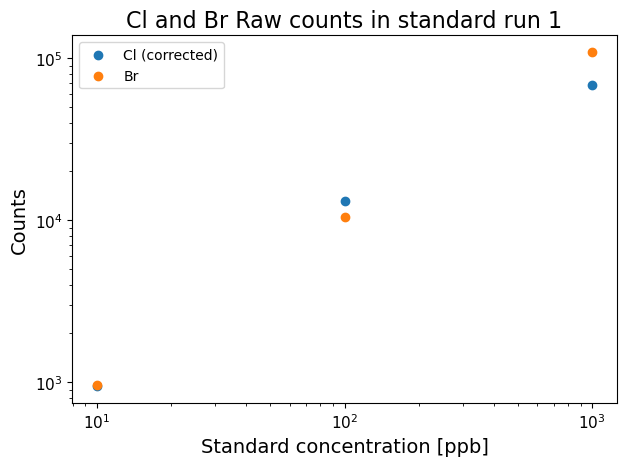

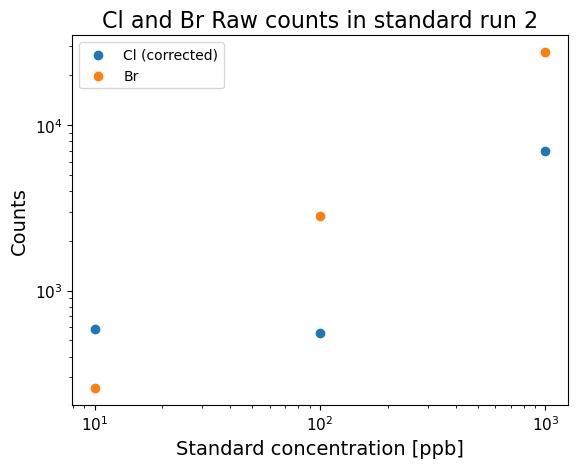

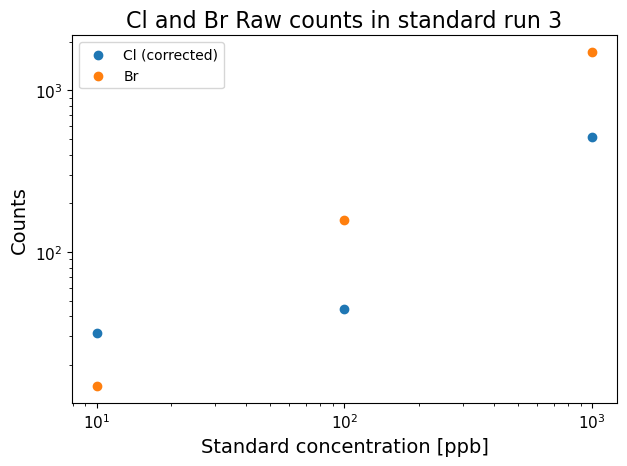

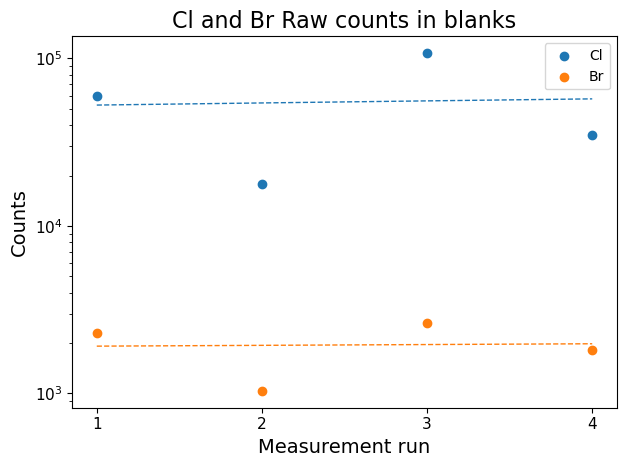

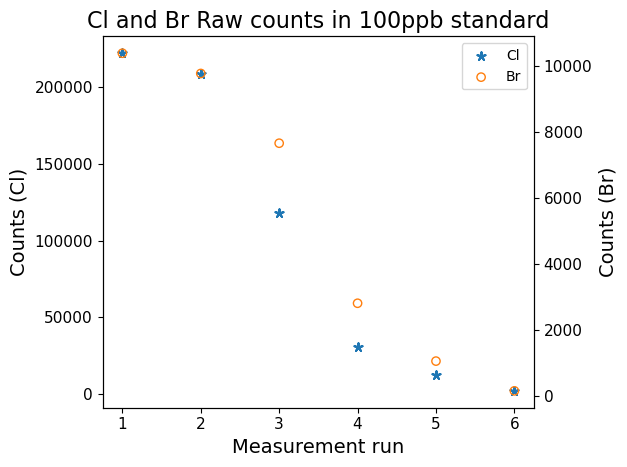

In [13]:
# Failed Bifluoride data plots and analysis.

# Plotting Cl and Br in the standard solutions.
standards_1 = ambif_data[0:3]
standards_2 = ambif_data[19:22]
standards_3 = ambif_data[32:]
concentrations = [10, 100, 1000]
CL_CORRECTION_1=209000
CL_CORRECTION_2=30000
CL_CORRECTION_3 = 2100
fig, ax = plt.subplots()
ax.scatter(concentrations, standards_1['CL(35)']-CL_CORRECTION_1, label='Cl (corrected)')
ax.scatter(concentrations, standards_1['Br(79)'], label='Br')
ax.set(title='Cl and Br Raw counts in standard run 1', xlabel='Standard concentration [ppb]', ylabel='Counts', xscale='log', yscale='log')
ax.legend()
plt.tight_layout()
plt.savefig('../img/cl_br_standards_run1.png', dpi=300)

fig, ax = plt.subplots()
ax.scatter(concentrations, standards_2['CL(35)']-CL_CORRECTION_2, label='Cl (corrected)')
ax.scatter(concentrations, standards_2['Br(79)'], label='Br')
ax.set(title='Cl and Br Raw counts in standard run 2', xlabel='Standard concentration [ppb]', ylabel='Counts', xscale='log', yscale='log')
ax.legend()

fig, ax = plt.subplots()
ax.scatter(concentrations, standards_3['CL(35)']-CL_CORRECTION_3, label='Cl (corrected)')
ax.scatter(concentrations, standards_3['Br(79)'], label='Br')
ax.set(title='Cl and Br Raw counts in standard run 3', xlabel='Standard concentration [ppb]', ylabel='Counts', xscale='log', yscale='log')
ax.legend()
plt.tight_layout()
plt.savefig('../img/cl_br_standards_run3.png', dpi=300)


# Plotting Cl and Br in the Bifluoride blanks.
ambif = ambif_data[3:7]
xx = np.arange(1,5,1)
ambif_br = ambif['Br(79)']
br_m, br_b = np.polyfit(xx, ambif_br, deg=1)
ambif_cl = ambif['CL(35)']
cl_m, cl_b = np.polyfit(xx, ambif_cl, deg=1)
print('Cl intercept: {}, Br intercept: {}'.format(cl_b, br_b))

fig, ax = plt.subplots()
ax.scatter(xx, ambif_cl, label='Cl', color='tab:blue')
ax.plot(xx, xx*cl_m + cl_b, color='tab:blue', ls='--', lw=1)
ax.scatter(xx, ambif_br, label='Br', color='tab:orange')
ax.plot(xx, xx*br_m + br_b, color='tab:orange', ls='--', lw=1)
ax.set(title='Cl and Br Raw counts in blanks', xlabel='Measurement run', ylabel='Counts', yscale='log')
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.legend()
plt.tight_layout()
plt.savefig('../img/cl_br_blanks.png', dpi=300)

# Plotting Cl and Br in all standard c=100 runs.
standard100 = ambif_data[ambif_data['Run'].str.startswith('100ClBr_Run')]
xx = np.arange(1,7,1)
fig, ax = plt.subplots()
sc1 = ax.scatter(xx, standard100['CL(35)'], label='Cl', color='tab:blue', marker=(5, 2)) # type: ignore
ax.set(title='Cl and Br Raw counts in 100ppb standard', xlabel='Measurement run', ylabel='Counts (Cl)')
# ax.set_zorder(10)

ax2 = ax.twinx()
sc2 = ax2.scatter(xx, standard100['Br(79)'], label='Br', marker='o', facecolors='none', edgecolors='tab:orange')
ax2.set_ylabel('Counts (Br)')
# ax2.set_zorder(9)

plots = [sc1, sc2]
labels = [p.get_label() for p in plots]
ax.legend(plots, labels) # type: ignore
plt.tight_layout()
plt.savefig('../img/icpms_halogen_sensitivity.png', dpi=300)


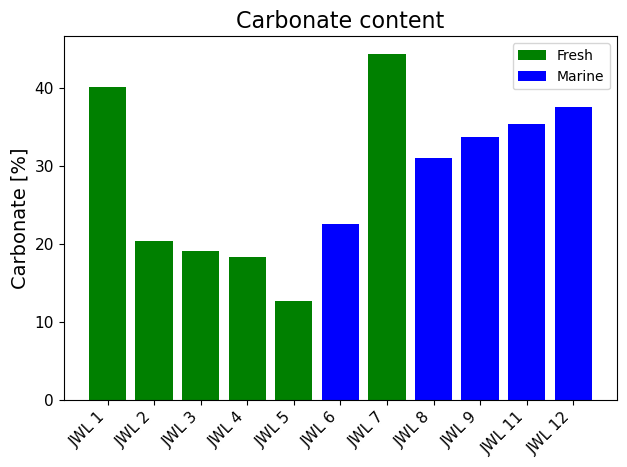

In [14]:
# Make a simple carbonate plot.
no_std = icpms[~icpms.Sample.str.contains('BCR2')]
fig, ax = plt.subplots()
bar_colors = [type_color[sample_type[rock(sample)]] for sample in icpms.Sample]
ax.bar(no_std.Sample, no_std['Carbonate']/10, color=bar_colors)
# Cheat to make the legend
ax.bar(no_std.Sample[0], no_std['Carbonate'][0]/10, color=bar_colors[0], label=FRESH)
ax.bar(no_std.Sample[5], no_std['Carbonate'][5]/10, color=bar_colors[5], label=MARINE)
ax.legend()
plt.xticks(rotation=45, ha='right')
ax.set_title('Carbonate content')
ax.set_ylabel('Carbonate [%]')
plt.tight_layout()
plt.savefig('../img/icpms_carbonate.png', dpi=300)